USED CAR PRICE PREDICTION
using Linear Regression
---
Dataset: https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler
import re
import pickle


In [2]:
df = pd.read_csv("used_cars.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 892.6 KB


In [4]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [5]:
df['price'] = df['price'].str.replace('[^0-9.]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [6]:
df['milage'] = df['milage'].str.replace('[^0-9.]', '', regex=True)
df['milage'] = pd.to_numeric(df['milage'], errors='coerce')

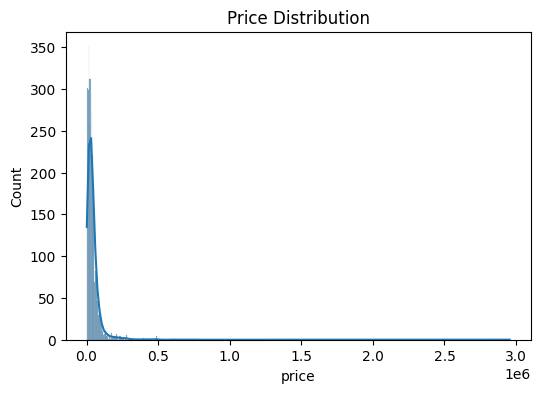

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

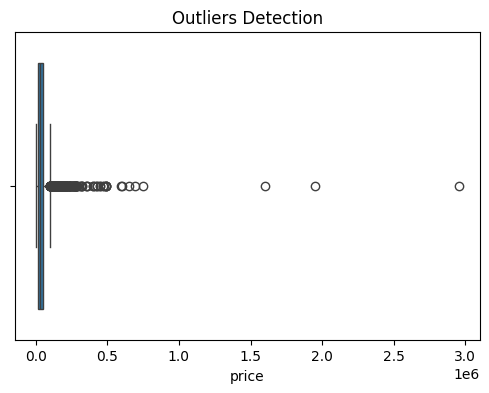

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])
plt.title("Outliers Detection")
plt.show()

In [9]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower) & (df['price'] <= upper)]

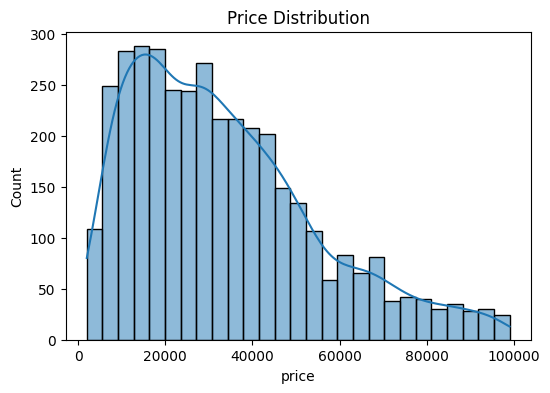

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

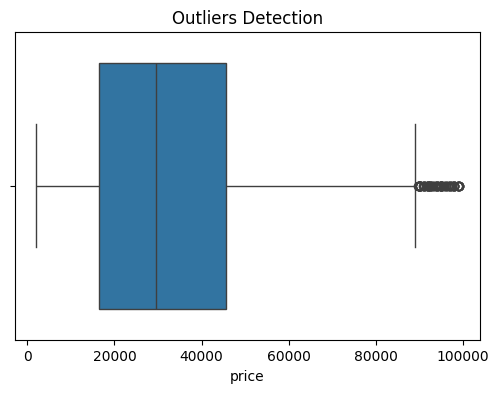

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])
plt.title("Outliers Detection")
plt.show()

In [12]:
def extract_litres(engine_str):
    match = re.search(r'([\d\.]+)\s*[Ll](?:iter|itre)?', str(engine_str))
    return float(match.group(1)) if match else np.nan

df['engine_size'] = df['engine'].apply(extract_litres)

In [13]:
df['accident'] = df['accident'].fillna('None reported')
df['has_accident'] = (
    df['accident'].str.contains('accident', case=False, na=False).astype(int)
)

In [14]:
df['clean_title'] = df['clean_title'].fillna('No')
df['clean_title_flag'] = (df['clean_title'] == 'Yes').astype(int)

In [15]:
fuel_map = {
    'Gasoline': 'Gasoline',
    'Hybrid': 'Hybrid',
    'Plug-In Hybrid': 'Hybrid',
    'Diesel': 'Diesel',
    'E85 Flex Fuel': 'Flex Fuel',
    '–': 'Unknown',
    'not supported': 'Unknown',
}
df['fuel_type'] = df['fuel_type'].map(fuel_map).fillna('Unknown')

In [16]:
def simplify_trans(t):
    t = str(t).upper()
    if 'M/T' in t or 'MANUAL' in t:
        return 'Manual'
    elif 'A/T' in t or 'AUTO' in t or 'CVT' in t or 'DUAL' in t:
        return 'Automatic'
    else:
        return 'Other'

df['transmission'] = df['transmission'].apply(simplify_trans)

In [17]:
df.isnull().sum()

brand                 0
model                 0
model_year            0
milage                0
fuel_type             0
engine                0
transmission          0
ext_col               0
int_col               0
accident              0
clean_title           0
price                 0
engine_size         207
has_accident          0
clean_title_flag      0
dtype: int64

In [18]:
df.dropna(subset=['price'], inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

for col in ['milage', 'engine_size']:
    df[col] = df[col].fillna(df[col].median())

In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 3765 entries, 0 to 4008
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             3765 non-null   str    
 1   model             3765 non-null   str    
 2   model_year        3765 non-null   int64  
 3   milage            3765 non-null   float64
 4   fuel_type         3765 non-null   str    
 5   engine            3765 non-null   str    
 6   transmission      3765 non-null   str    
 7   ext_col           3765 non-null   str    
 8   int_col           3765 non-null   str    
 9   accident          3765 non-null   str    
 10  clean_title       3765 non-null   str    
 11  price             3765 non-null   int64  
 12  engine_size       3765 non-null   float64
 13  has_accident      3765 non-null   int32  
 14  clean_title_flag  3765 non-null   int32  
dtypes: float64(2), int32(2), int64(2), str(9)
memory usage: 857.5 KB


In [20]:
y = np.log1p(df['price'])
X = df.drop('price', axis=1)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [22]:
train_df = X_train.copy()
train_df['price'] = y_train

model_mean = train_df.groupby('model')['price'].mean()

In [23]:
ext_mean = train_df.groupby('ext_col')['price'].mean()
int_mean = train_df.groupby('int_col')['price'].mean()

In [24]:
X_train['model_encoded'] = X_train['model'].map(model_mean)
X_test['model_encoded'] = X_test['model'].map(model_mean).fillna(model_mean.mean())

X_train['ext_col_encoded'] = X_train['ext_col'].map(ext_mean)
X_test['ext_col_encoded'] = X_test['ext_col'].map(ext_mean).fillna(ext_mean.mean())

X_train['int_col_encoded'] = X_train['int_col'].map(int_mean)
X_test['int_col_encoded'] = X_test['int_col'].map(int_mean).fillna(int_mean.mean())

In [25]:
X_train.drop(['model','ext_col','int_col'], axis=1, inplace=True)
X_test.drop(['model','ext_col','int_col'], axis=1, inplace=True)

In [26]:
df.info()

<class 'pandas.DataFrame'>
Index: 3765 entries, 0 to 4008
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             3765 non-null   str    
 1   model             3765 non-null   str    
 2   model_year        3765 non-null   int64  
 3   milage            3765 non-null   float64
 4   fuel_type         3765 non-null   str    
 5   engine            3765 non-null   str    
 6   transmission      3765 non-null   str    
 7   ext_col           3765 non-null   str    
 8   int_col           3765 non-null   str    
 9   accident          3765 non-null   str    
 10  clean_title       3765 non-null   str    
 11  price             3765 non-null   int64  
 12  engine_size       3765 non-null   float64
 13  has_accident      3765 non-null   int32  
 14  clean_title_flag  3765 non-null   int32  
dtypes: float64(2), int32(2), int64(2), str(9)
memory usage: 857.5 KB


In [27]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [28]:
df.info()

<class 'pandas.DataFrame'>
Index: 3765 entries, 0 to 4008
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             3765 non-null   str    
 1   model             3765 non-null   str    
 2   model_year        3765 non-null   int64  
 3   milage            3765 non-null   float64
 4   fuel_type         3765 non-null   str    
 5   engine            3765 non-null   str    
 6   transmission      3765 non-null   str    
 7   ext_col           3765 non-null   str    
 8   int_col           3765 non-null   str    
 9   accident          3765 non-null   str    
 10  clean_title       3765 non-null   str    
 11  price             3765 non-null   int64  
 12  engine_size       3765 non-null   float64
 13  has_accident      3765 non-null   int32  
 14  clean_title_flag  3765 non-null   int32  
dtypes: float64(2), int32(2), int64(2), str(9)
memory usage: 857.5 KB


In [29]:
columns = X_train.columns
pickle.dump(columns, open("columns.pkl", "wb"))

In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
y_pred_log = model.predict(X_test)

In [33]:
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

In [34]:
r2 = r2_score(y_test_actual, y_pred_actual)
print("R² Score:", r2)

R² Score: 0.776915139530484


In [35]:
mae = mean_absolute_error(y_test_actual, y_pred_actual)
print("MAE:", mae)

MAE: 6437.355030515629


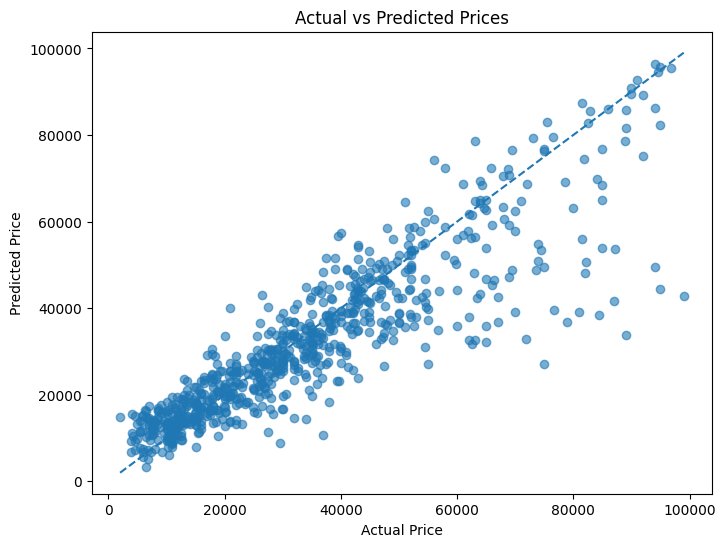

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(y_test_actual, y_pred_actual, alpha=0.6)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    linestyle='--'
)

plt.show()

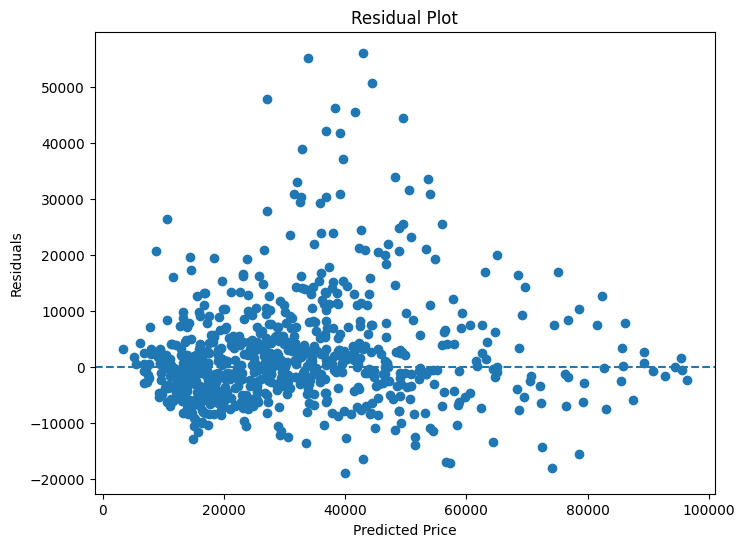

In [37]:
residuals = y_test_actual - y_pred_actual

plt.figure(figsize=(8,6))
plt.scatter(y_pred_actual, residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [38]:
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(model_mean, open("model_mean.pkl", "wb"))
pickle.dump(ext_mean, open("ext_mean.pkl", "wb"))
pickle.dump(int_mean, open("int_mean.pkl", "wb"))